# Eliminación de Outliers con Rango Intercuartílico (IQR)

Dataset: `Citas_Digital_Filtrado.csv`

Columnas numéricas a revisar: `PDM`, `SDC`, `Venta`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Citas_Digital_Filtrado.csv")
df.head()

,BDC,Fecha,Nombre Cliente,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?
0,Saul,NaN,Guillermo,Finalizado,0.9,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s..."
1,Saul,NaN,Roberto,Finalizado,0.4,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso
2,Saul,NaN,Irving,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso
3,Saul,NaN,Oswaldo,Venta,0.9,0.0,0.0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as..."
4,Saul,NaN,Rodrigo,Finalizado,0.9,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...


## 1. Diagramas de caja ANTES de eliminar outliers

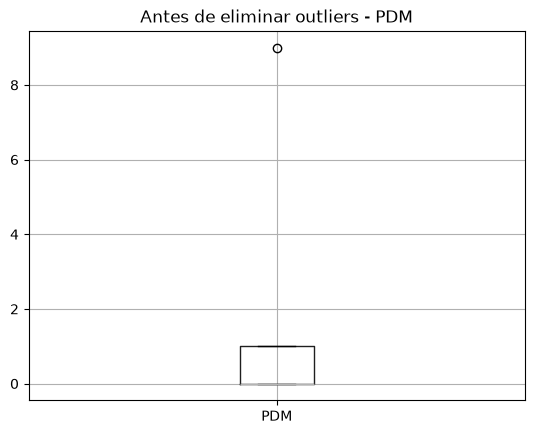

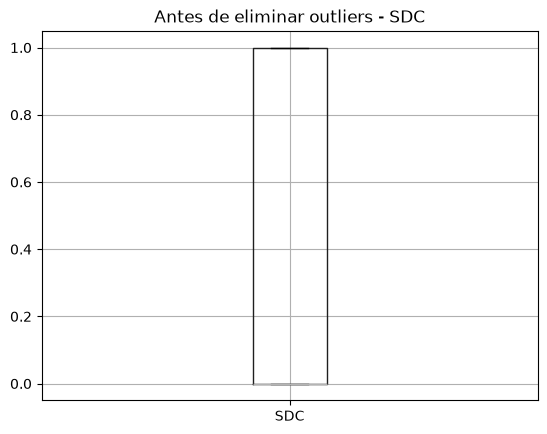

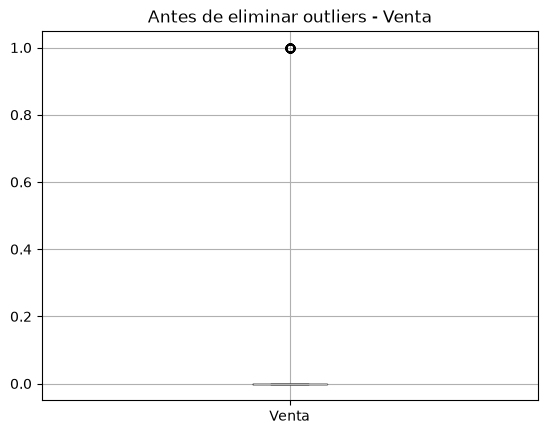

In [2]:
columnas_numericas = ["PDM", "SDC", "Venta"]

for col in columnas_numericas:
    df.boxplot(column=col)
    plt.title(f"Antes de eliminar outliers - {col}")
    plt.show()

## 2. Eliminar outliers con el método del Rango Intercuartílico (IQR)

Para cada columna se calcula:
- Q1 (percentil 25) y Q3 (percentil 75)
- IQR = Q3 - Q1
- Límite inferior = Q1 - 1.5 * IQR
- Límite superior = Q3 + 1.5 * IQR

Y se conservan solo los datos dentro de esos límites.

In [3]:
df_limpio = df.copy()

for col in columnas_numericas:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]

print("Filas originales:", len(df))
print("Filas despues de eliminar outliers:", len(df_limpio))

Filas originales: 673
Filas despues de eliminar outliers: 612


## 3. Diagramas de caja DESPUÉS de eliminar outliers

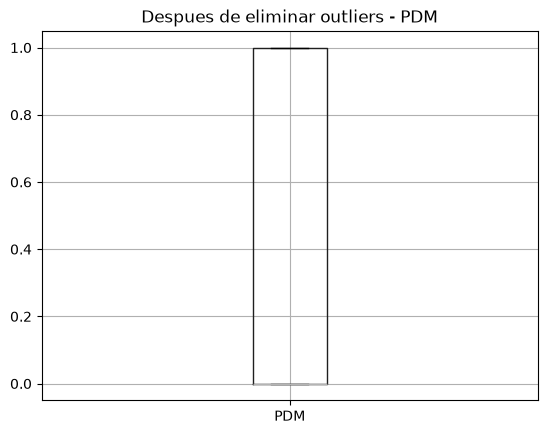

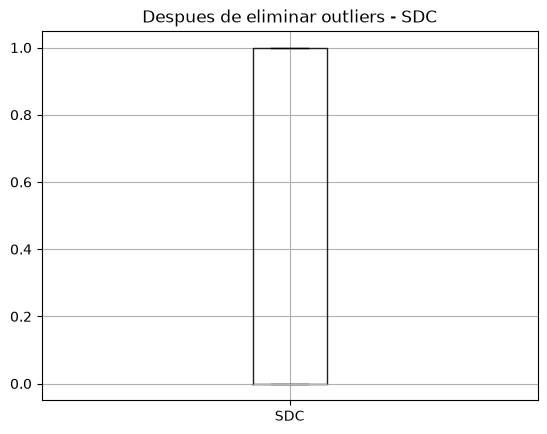

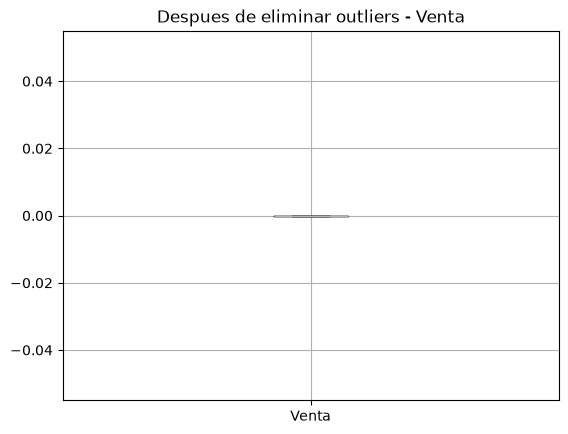

In [4]:
for col in columnas_numericas:
    df_limpio.boxplot(column=col)
    plt.title(f"Despues de eliminar outliers - {col}")
    plt.show()

## 4. Guardar el archivo limpio (sin outliers)

In [5]:
df_limpio.to_csv("Citas_Digital_Sin_Outliers.csv", index=False)